# Análise Completa do Algoritmo KNN com Diferentes Métricas de Distância

Este notebook possui como objetivo demonstrar o funcionamento do algoritmo K-Nearest Neighbors (KNN) utilizando diferentes métricas de distância:

- Distância Euclidiana
- Distância de Manhattan
- Distância de Minkowski
- Distância de Hamming

Serão utilizados dois datasets:

- `Mall_Customers.csv`
- `Social_Network_Ads.csv`

Além disso, o notebook demonstra:

- Cenários de overfitting
- Cenários ideais
- Cenários de underfitting
- Visualizações bidimensionais
- Visualizações tridimensionais
- Comparação entre métricas
- Impacto da normalização
- Funcionamento interno do algoritmo

## Funcionamento do KNN

Dado um conjunto de elementos de parâmetro, ao fornecer um novo dado `x` , o KNN obtém até `K` elementos mais próximos de `x` e o classifica conforme a pluralidade dos elementos mais próximos deste, conforme pode ser visualizado abaixo: 

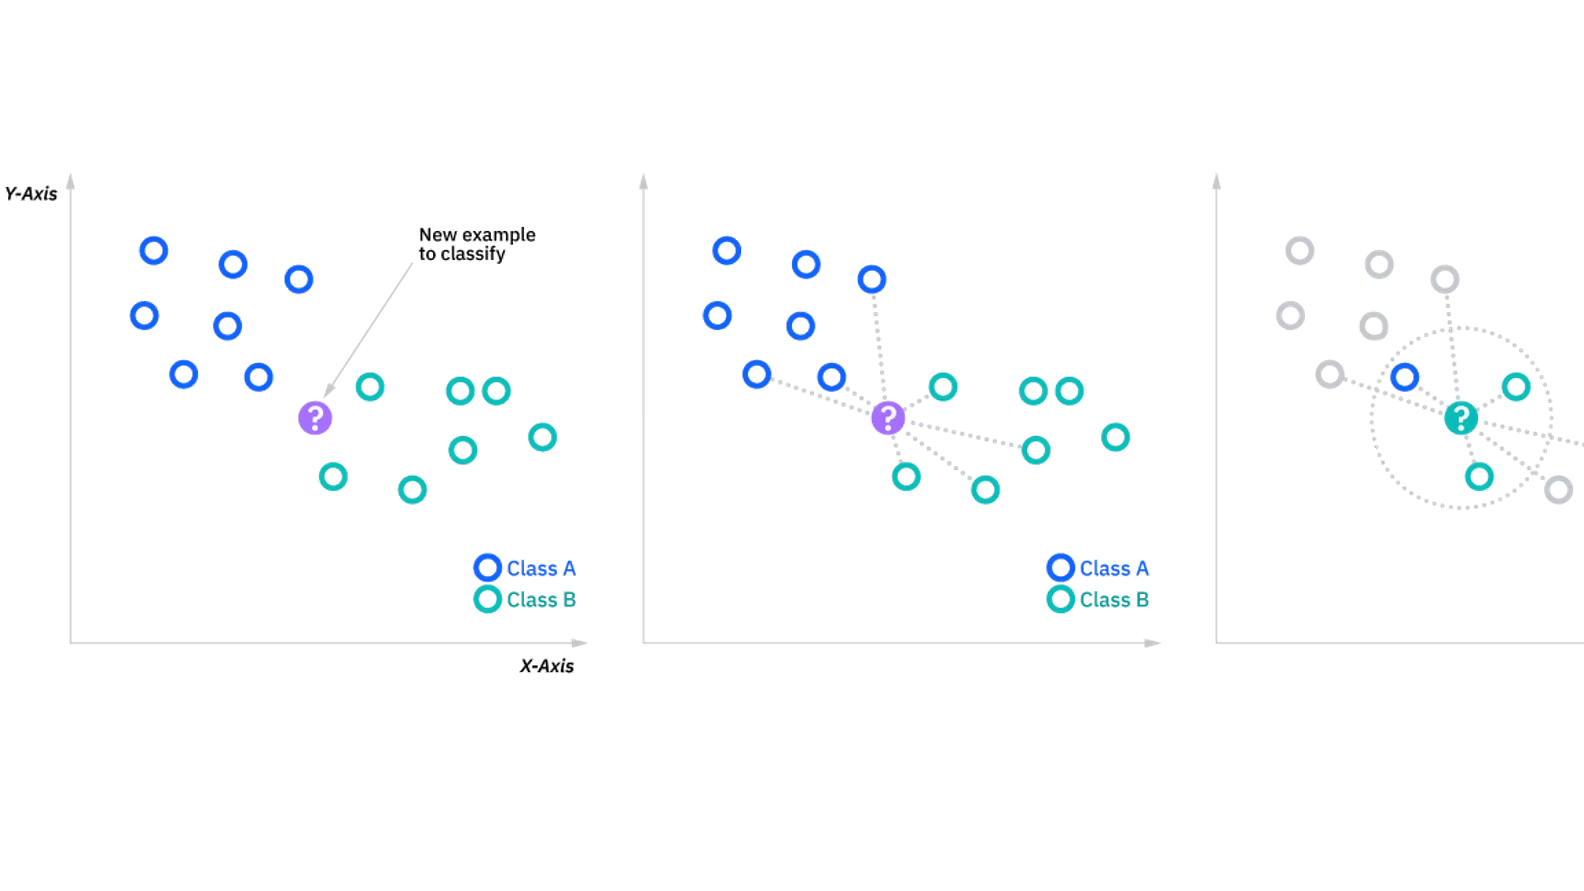


---

> Execute as células sequencialmente para garantir o funcionamento correto deste notebook.
>
> Isto garante que os módulos utilizados e os datasets de treinamento declarados estejam devidamente computados antes da execução
> do algoritmo.

In [69]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from src.knn import KNN

from src.distances import (
    euclidean_distance,
    manhattan_distance,
    minkowski_distance,
    hamming_distance
)

from src.metrics import (
    knn_accuracy,
    knn_compare
)

## Leitura dos Dados

### Dataset: Mall Customers

In [70]:
mall_df = pd.read_csv('../data/Mall_Customers.csv')

mall_df.head()

mall_df.info()

mall_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Dataset: Social Netword Ads

In [71]:
social_df = pd.read_csv('../data/Social_Network_Ads.csv')

social_df.head()

social_df.info()

social_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


## Pré-processamento de Dados
O algoritmo KNN trabalha com valores numéricos, portanto precisamos converter os valores categóricos em numéricos.

### Mall Customers

In [72]:
encoder = LabelEncoder()

mall_df['Genre'] = encoder.fit_transform(mall_df['Genre'])

mall_df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


### Social Network Ads

In [73]:
social_df['Gender'] = encoder.fit_transform(social_df['Gender'])

social_df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


## Definição de Features e Targets

### Mall Customers
Esse dataset originalmente não possui uma classe alvo, então criaremos uma classificação artificial.

- Clientes com `Spending Score` > 50 serão considerados 'Bons Compradores'

In [74]:
mall_df['HighSpender'] = (
    mall_df['Spending Score (1-100)'] > 50
).astype(int)

X_mall = mall_df[[
    'Genre',
    'Age',
    'Annual Income (k$)'
]].values

y_mall = mall_df['HighSpender'].values

### Social Network Ads
Neste dataset, queremos prever se o usuário comprará ou não um produto.

A coluna alvo será: `Purchased`

In [75]:
X_social = social_df[[
    'Gender',
    'Age',
    'EstimatedSalary'
]].values


y_social = social_df['Purchased'].values

## Separação em Treinos e Testes

### Mall Customers

In [76]:
X_train_mall, X_test_mall, y_train_mall, y_test_mall = train_test_split(
    X_mall,
    y_mall,
    test_size=0.2,
    random_state=42
)

### Social Network Ads

In [77]:
X_train_social, X_test_social, y_train_social, y_test_social = train_test_split(
    X_social,
    y_social,
    test_size=0.2,
    random_state=42
)

## Normalização dos Dados

O algoritmo KNN é extremamente sensível à escala dos dados.

Exemplo:
- Idade → valores pequenos
- Salário → valores muito grandes

Sem normalização, o salário dominaria o cálculo da distância.

In [78]:
scaler = StandardScaler()

X_train_social = scaler.fit_transform(X_train_social)
X_test_social = scaler.transform(X_test_social)

X_train_mall = scaler.fit_transform(X_train_mall)
X_test_mall = scaler.transform(X_test_mall)

## Executando o KNN

### Mall Customers

In [79]:
distance_metrics = {
    'Euclidiana': euclidean_distance,
    'Manhattan': manhattan_distance,
    'Minkowski': lambda x, y: minkowski_distance(x, y, order=3),
    'Hamming': hamming_distance
}


results_mall = {}

for metric_name, distance_function in distance_metrics.items():

    print(f'\n===== MÉTRICA: {metric_name} =====')

    model = KNN(
        distance_formula=distance_function,
        neighbors=9,
        k_value_strategy='ideal'
    )

    model.fit(X_train_mall, y_train_mall)

    predictions = model.predict(X_test_mall)

    accuracy = knn_accuracy(y_test_mall, predictions)

    results_mall[metric_name] = accuracy

    print(f'Acurácia: {accuracy:.4f}')

    comparison = knn_compare(
        X_test_mall,
        y_test_mall,
        predictions
    )

    display(comparison.head())


===== MÉTRICA: Euclidiana =====
Acurácia: 0.6250


,Ponto,Atributo Esperado,Atributo Previsto,Precisão
0,[ 1.14840785 -1.07958231 -0.02219935],1,1,0.625
1,[ 1.14840785 -1.22437122 -1.48689856],1,1,0.625
2,[ 1.14840785 1.52661807 -1.12072376],0,0,0.625
3,[ 1.14840785 -0.35563776 0.6369153 ],0,1,0.625
4,[1.14840785 1.45422361 0.38059294],0,0,0.625



===== MÉTRICA: Manhattan =====
Acurácia: 0.6000


,Ponto,Atributo Esperado,Atributo Previsto,Precisão
0,[ 1.14840785 -1.07958231 -0.02219935],1,0,0.6
1,[ 1.14840785 -1.22437122 -1.48689856],1,1,0.6
2,[ 1.14840785 1.52661807 -1.12072376],0,0,0.6
3,[ 1.14840785 -0.35563776 0.6369153 ],0,1,0.6
4,[1.14840785 1.45422361 0.38059294],0,0,0.6



===== MÉTRICA: Minkowski =====
Acurácia: 0.6750


,Ponto,Atributo Esperado,Atributo Previsto,Precisão
0,[ 1.14840785 -1.07958231 -0.02219935],1,1,0.675
1,[ 1.14840785 -1.22437122 -1.48689856],1,1,0.675
2,[ 1.14840785 1.52661807 -1.12072376],0,0,0.675
3,[ 1.14840785 -0.35563776 0.6369153 ],0,1,0.675
4,[1.14840785 1.45422361 0.38059294],0,0,0.675



===== MÉTRICA: Hamming =====
Acurácia: 0.4750


,Ponto,Atributo Esperado,Atributo Previsto,Precisão
0,[ 1.14840785 -1.07958231 -0.02219935],1,0,0.475
1,[ 1.14840785 -1.22437122 -1.48689856],1,1,0.475
2,[ 1.14840785 1.52661807 -1.12072376],0,1,0.475
3,[ 1.14840785 -0.35563776 0.6369153 ],0,1,0.475
4,[1.14840785 1.45422361 0.38059294],0,1,0.475


### Social Network Ads

In [80]:
results_social = {}

for metric_name, distance_function in distance_metrics.items():

    print(f'\n===== MÉTRICA: {metric_name} =====')

    model = KNN(
        distance_formula=distance_function,
        neighbors=9,
        k_value_strategy='ideal'
    )

    model.fit(X_train_social, y_train_social)

    predictions = model.predict(X_test_social)

    accuracy = knn_accuracy(y_test_social, predictions)

    results_social[metric_name] = accuracy

    print(f'Acurácia: {accuracy:.4f}')

    comparison = knn_compare(
        X_test_social,
        y_test_social,
        predictions
    )

    display(comparison.head())


===== MÉTRICA: Euclidiana =====
Acurácia: 0.9125


,Ponto,Atributo Esperado,Atributo Previsto,Precisão
0,[-1. 0.79753468 -1.40447546],0,1,0.9125
1,[-1. 2.07309956 0.51542886],1,1,0.9125
2,[-1. -0.96863208 -0.76450736],0,0,0.9125
3,[-1. 0.99377543 0.74814454],1,0,0.9125
4,[-1. -0.87051171 -1.22993871],0,0,0.9125



===== MÉTRICA: Manhattan =====
Acurácia: 0.9250


,Ponto,Atributo Esperado,Atributo Previsto,Precisão
0,[-1. 0.79753468 -1.40447546],0,1,0.925
1,[-1. 2.07309956 0.51542886],1,1,0.925
2,[-1. -0.96863208 -0.76450736],0,0,0.925
3,[-1. 0.99377543 0.74814454],1,1,0.925
4,[-1. -0.87051171 -1.22993871],0,0,0.925



===== MÉTRICA: Minkowski =====
Acurácia: 0.9125


,Ponto,Atributo Esperado,Atributo Previsto,Precisão
0,[-1. 0.79753468 -1.40447546],0,1,0.9125
1,[-1. 2.07309956 0.51542886],1,1,0.9125
2,[-1. -0.96863208 -0.76450736],0,0,0.9125
3,[-1. 0.99377543 0.74814454],1,0,0.9125
4,[-1. -0.87051171 -1.22993871],0,0,0.9125



===== MÉTRICA: Hamming =====
Acurácia: 0.8125


,Ponto,Atributo Esperado,Atributo Previsto,Precisão
0,[-1. 0.79753468 -1.40447546],0,0,0.8125
1,[-1. 2.07309956 0.51542886],1,0,0.8125
2,[-1. -0.96863208 -0.76450736],0,0,0.8125
3,[-1. 0.99377543 0.74814454],1,1,0.8125
4,[-1. -0.87051171 -1.22993871],0,0,0.8125


## Comparando Resultados

### Mall Customers

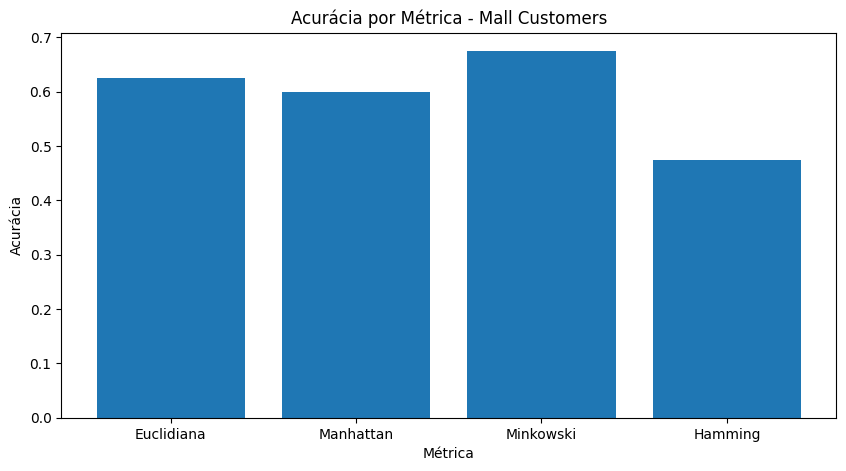

In [81]:
plt.figure(figsize=(10, 5))

plt.bar(results_mall.keys(), results_mall.values())

plt.title('Acurácia por Métrica - Mall Customers')
plt.xlabel('Métrica')
plt.ylabel('Acurácia')

plt.show()

### Social Network Ads

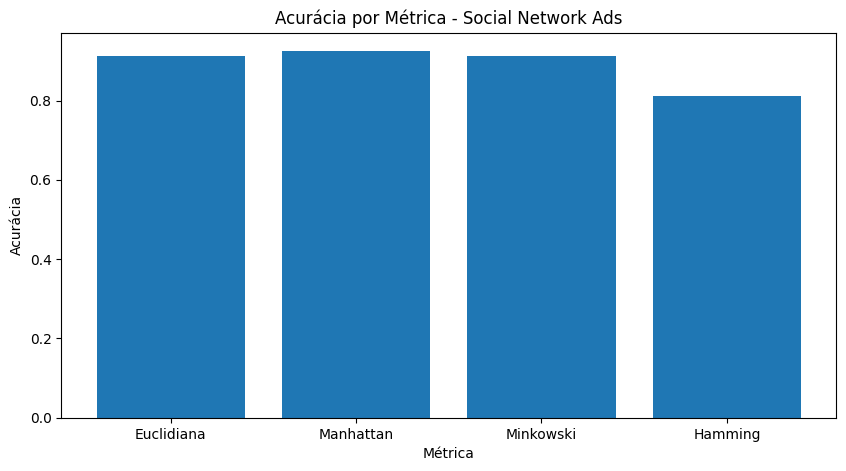

In [82]:
plt.figure(figsize=(10, 5))

plt.bar(results_social.keys(), results_social.values())

plt.title('Acurácia por Métrica - Social Network Ads')
plt.xlabel('Métrica')
plt.ylabel('Acurácia')

plt.show()

## Cenário de Overfitting

No overfitting, o modelo memoriza os dados.

Isso acontece quando:
- K é muito pequeno
- normalmente K = 1

In [83]:
overfit_model = KNN(
    distance_formula=euclidean_distance,
    neighbors=9,
    k_value_strategy='overfitting'
)

overfit_model.fit(X_train_social, y_train_social)

overfit_predictions = overfit_model.predict(X_test_social)

overfit_accuracy = knn_accuracy(
    y_test_social,
    overfit_predictions
)

print(f'Acurácia Overfitting: {overfit_accuracy:.4f}')

Acurácia Overfitting: 0.8875


## Cenário Ideal

No cenário ideal:
- o modelo consegue generalizar bem
- ignora pequenos ruídos
- mantém boa precisão

In [84]:
ideal_model = KNN(
    distance_formula=euclidean_distance,
    neighbors=9,
    k_value_strategy='ideal'
)

ideal_model.fit(X_train_social, y_train_social)

ideal_predictions = ideal_model.predict(X_test_social)

ideal_accuracy = knn_accuracy(
    y_test_social,
    ideal_predictions
)

print(f'Acurácia Ideal: {ideal_accuracy:.4f}')

Acurácia Ideal: 0.9125


## Cenário de Underfitting

No underfitting:
- K é muito alto
- o modelo simplifica demais os padrões
- perde precisão

In [85]:
underfit_model = KNN(
    distance_formula=euclidean_distance,
    neighbors=25,
    k_value_strategy='underfitting'
)

underfit_model.fit(X_train_social, y_train_social)

underfit_predictions = underfit_model.predict(X_test_social)

underfit_accuracy = knn_accuracy(
    y_test_social,
    underfit_predictions
)

print(f'Acurácia Underfitting: {underfit_accuracy:.4f}')

Acurácia Underfitting: 0.8625


## Visualização Tridimensional

A visualização tridimensional ajuda a compreender:
- agrupamentos
- vizinhança
- separação entre classes

### Exemplo com Social Network Ads

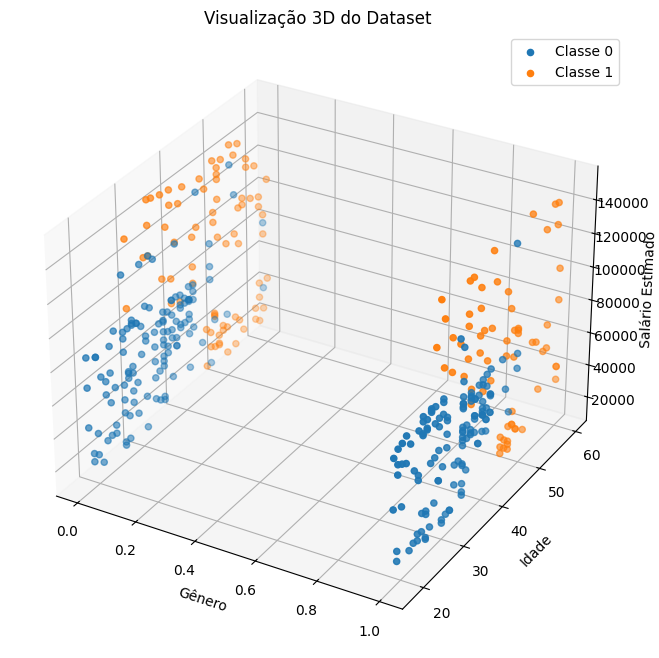

In [86]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

for label in np.unique(y_social):

    ax.scatter(
        X_social[y_social == label][:, 0],
        X_social[y_social == label][:, 1],
        X_social[y_social == label][:, 2],
        label=f'Classe {label}'
    )

ax.set_xlabel('Gênero')
ax.set_ylabel('Idade')
ax.set_zlabel('Salário Estimado')

ax.set_title('Visualização 3D do Dataset')

plt.legend()
plt.show()

## Matriz de Confusão

A matriz de confusão mostra:
- acertos
- falsos positivos
- falsos negativos

In [87]:
cm = confusion_matrix(y_test_social, ideal_predictions)

print(cm)

[[49  3]
 [ 4 24]]


## Relatório de Classificação

In [88]:
report = classification_report(
    y_test_social,
    ideal_predictions
)

print(report)

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        52
           1       0.89      0.86      0.87        28

    accuracy                           0.91        80
   macro avg       0.91      0.90      0.90        80
weighted avg       0.91      0.91      0.91        80



## Comparação Entre Valores de K

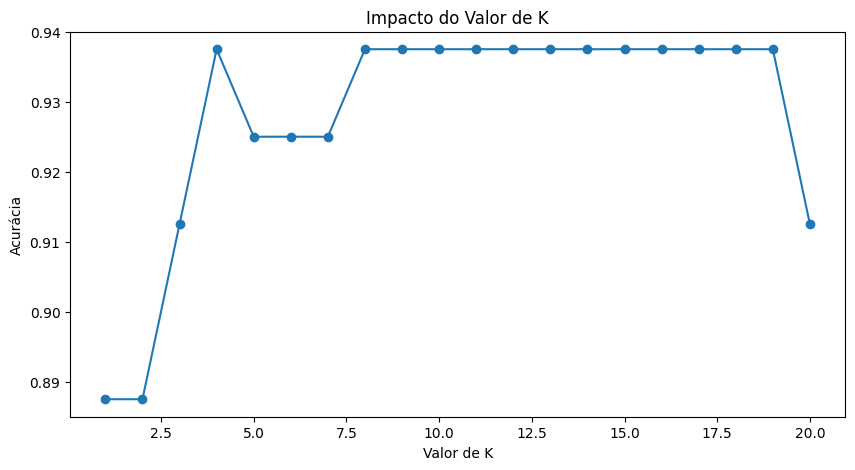

In [89]:
k_values = range(1, 21)

accuracies = []

for k in k_values:

    model = KNN(
        distance_formula=euclidean_distance,
        neighbors=k,
        k_value_strategy='underfitting'
    )

    model.fit(X_train_social, y_train_social)

    predictions = model.predict(X_test_social)

    accuracy = knn_accuracy(y_test_social, predictions)

    accuracies.append(accuracy)

plt.figure(figsize=(10, 5))

plt.plot(k_values, accuracies, marker='o')

plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.title('Impacto do Valor de K')

plt.show()

## Análise das Métricas

### Distância Euclidiana

![euclidian.png](../images/euclidian.png)
Fonte: https://towardsdatascience.com/optimising-pairwise-euclidean-distance-calculations-using-python-fc020112c984/

Características:
- mede distância geométrica
- muito utilizada em dados contínuos
- geralmente possui melhor desempenho em datasets numéricos

### Distância Manhattan

![manhattan.png](../images/manhattan.png)
Fonte: https://medidassimdist.wordpress.com/distancia-de-manhattan/

Características:
- soma distâncias absolutas
- menos sensível a outliers
- útil em movimentações em grade

### Distância Minkowski

![minkowski.png](../images/minkowski.png)
Fonte: https://aiml.com/what-is-minkowski-distance/

Características:
- generalização das distâncias Euclidiana e Manhattan
- parâmetro p controla o comportamento

### Distância de Hamming

![hamming.png](../images/hamming.png)
Fonte: https://marketplace.uipath.com/listings/hamming-distance-string-matching-algorithm

Características:
- ideal para dados binários
- funciona melhor com atributos categóricos
- não é muito adequada para dados contínuos